In [1]:
import warnings
warnings.filterwarnings("ignore")
import os
os.environ["NIXTLA_ID_AS_COL"] = "true"
import numpy as np
np.set_printoptions(suppress=True)
np.random.seed(1)
import random
random.seed(1)
import pandas as pd
pd.set_option("max_colwidth", 100)
pd.set_option("display.precision", 3)
from utilsforecast.plotting import plot_series as plot_series_utils
import seaborn as sns
sns.set_style("whitegrid")
import matplotlib.pyplot as plt
plt.style.use("ggplot")
plt.rcParams.update({
    "figure.figsize": (8, 5),
    "figure.dpi": 100,
    "savefig.dpi": 300,
    "figure.constrained_layout.use": True,
    "axes.titlesize": 12,
    "axes.labelsize": 10,
    "xtick.labelsize": 9,
    "ytick.labelsize": 9,
    "legend.fontsize": 9,
    "legend.title_fontsize": 10,
    "grid.alpha": 1.0,
})
import matplotlib as mpl
from cycler import cycler
mpl.rcParams['axes.prop_cycle'] = cycler(color=["#000000", "#000000"])
from fpppy.utils import plot_series

mpl.colormaps.register(
    mpl.colors.ListedColormap(
        ["#000000", "#2f2fff"], name="black_and_blue"),
    force=True,
)
mpl.colormaps.register(
    mpl.colors.ListedColormap(
        ["#000000", "#D55E00"], name="black_and_orange"),
    force=True,
)
mpl.colormaps.register(
    mpl.colors.ListedColormap(
        ["#000000", "#000000"], name="black"),
    force=True,
)
mpl.colormaps.register(
    mpl.colors.ListedColormap(
        ["#000000", "#0072B2", "#D55E00"],
        name='black_and_2color',
    ),
    force=True
)
mpl.colormaps.register(
    mpl.colors.ListedColormap(
        ["#000000", "#D55E00", "#0072B2", "#009E73"],
        name='black_and_3color',
    ),
    force=True
)
mpl.colormaps.register(
    mpl.colors.ListedColormap(
        ["#000000", "#D55E00", "#0072B2", "#009E73", "#CC79A7"],
        name='black_and_4color',
    ),
    force=True
)
mpl.colormaps.register(
    mpl.colors.ListedColormap(
        ["#D55E00", "#0072B2", "#009E73", "#CC79A7"],
        name='r_colors',
    ),
    force=True
)

In [4]:
from functools import partial, reduce

import statsmodels.api as sm
from matplotlib.ticker import MaxNLocator
from statsforecast import StatsForecast
from statsforecast.models import MSTL, AutoETS, AutoARIMA, ARIMA
from statsmodels.graphics.tsaplots import plot_acf
from statsmodels.tsa.api import VAR
from utilsforecast.evaluation import evaluate
from utilsforecast.feature_engineering import trend, fourier, pipeline
from utilsforecast.losses import rmse, mae, mape, mase
from utilsforecast.preprocessing import fill_gaps

In [5]:
us_change = (
    pd.read_csv("US_change.csv", parse_dates=["ds"])
    .rename(columns={"y": "Consumption"})
    .drop(columns=["unique_id"])
    .set_index("ds").asfreq("QS")
)
from statsmodels.tsa.api import VAR
model = VAR(us_change)
fit_aic = model.fit(ic="aic")
fit_bic = model.fit(ic="bic")
print("Lags selected by AIC:", fit_aic.k_ar)
print("Lags selected by BIC:", fit_bic.k_ar)

Lags selected by AIC: 5
Lags selected by BIC: 1


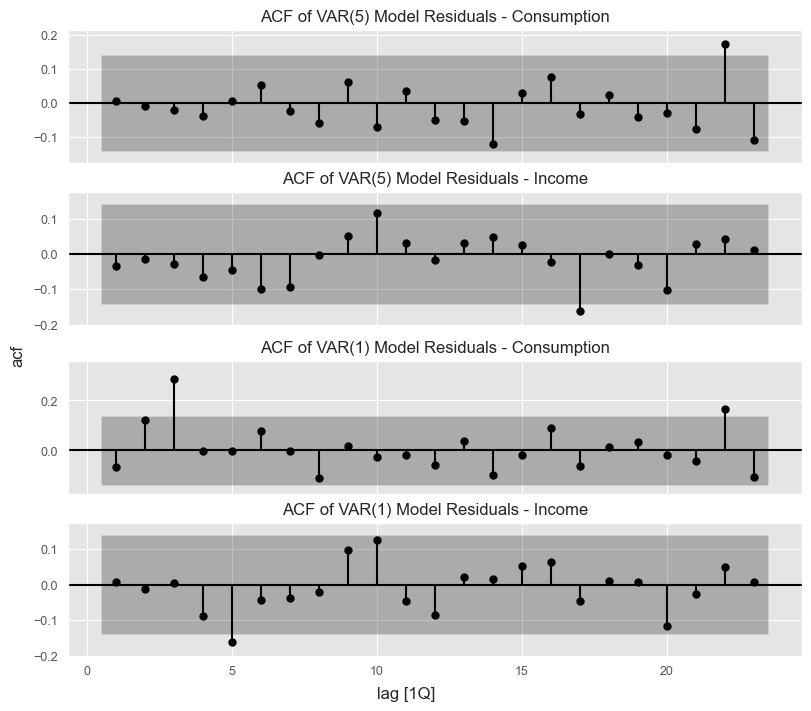

In [6]:
fig, axes = plt.subplots(4, figsize=(8, 7), sharex=True)

def plot_one_acf(series, name, ax):
    plot_acf(
        series, ax=ax,
        title=f"ACF of {name} Model Residuals - {series.name}",
        zero=False, auto_ylims=True, bartlett_confint=False)

plot_one_acf(fit_aic.resid["Consumption"], "VAR(5)", ax=axes[0])
plot_one_acf(fit_aic.resid["Income"], "VAR(5)", ax=axes[1])
plot_one_acf(fit_bic.resid["Consumption"], "VAR(1)", ax=axes[2])
plot_one_acf(fit_bic.resid["Income"], "VAR(1)", ax=axes[3])
fig.supylabel("acf")
fig.supxlabel("lag [1Q]")
plt.show()

In [7]:
lag_order = fit_aic.k_ar
y = us_change.tail(lag_order).to_numpy()
fc80 = fit_aic.forecast_interval(y, steps=8, alpha=0.2)
fc95 = fit_aic.forecast_interval(y, steps=8, alpha=0.05)
fc_var5 = pd.concat([
    pd.DataFrame({
        "unique_id": column,
        "ds": pd.date_range(start="2019-07-01", periods=8, freq="QS"),
        "VAR_5": fc80[0][:, i],
        "VAR_5-lo-80": fc80[1][:, i],
        "VAR_5-hi-80": fc80[2][:, i],
        "VAR_5-lo-95": fc95[1][:, i],
        "VAR_5-hi-95": fc95[2][:, i],
    })
    for (i, column) in enumerate(["Consumption", "Income"])
])

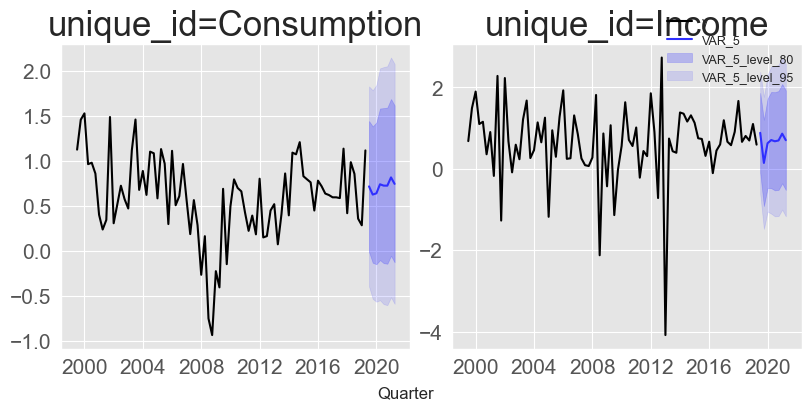

In [8]:
columns = ["Consumption", "Income"]
plot_us_change = (
    us_change[columns]
    .reset_index()
    .melt(id_vars="ds", var_name="unique_id", value_name="y")
)
fig, axes = plt.subplots(1, 2, figsize=(8, 4))
plot_series(plot_us_change, fc_var5, level=[80, 95],
    max_insample_length=4 * 20, xlabel="", ylabel="",
    palette="black_and_blue", ax=axes, rm_legend=False)
fig.supxlabel("Quarter")
fig